<a href="https://colab.research.google.com/github/KhusbuBubna123/BreastCancerDetection/blob/main/BrainTumorClassificationCNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import os
import tqdm
import random
import PIL
import tensorflow as tf
from keras.preprocessing.image import load_img
warnings.filterwarnings('ignore')
import seaborn as sns

In [10]:
!unzip BrainTumorDataset.zip
#!unzip Tuberculosis_Dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: Training/glioma/Tr-gl_279.jpg  
  inflating: Training/glioma/Tr-gl_28.jpg  
  inflating: Training/glioma/Tr-gl_280.jpg  
  inflating: Training/glioma/Tr-gl_281.jpg  
  inflating: Training/glioma/Tr-gl_282.jpg  
  inflating: Training/glioma/Tr-gl_283.jpg  
  inflating: Training/glioma/Tr-gl_284.jpg  
  inflating: Training/glioma/Tr-gl_285.jpg  
  inflating: Training/glioma/Tr-gl_286.jpg  
  inflating: Training/glioma/Tr-gl_287.jpg  
  inflating: Training/glioma/Tr-gl_288.jpg  
  inflating: Training/glioma/Tr-gl_289.jpg  
  inflating: Training/glioma/Tr-gl_29.jpg  
  inflating: Training/glioma/Tr-gl_290.jpg  
  inflating: Training/glioma/Tr-gl_291.jpg  
  inflating: Training/glioma/Tr-gl_292.jpg  
  inflating: Training/glioma/Tr-gl_293.jpg  
  inflating: Training/glioma/Tr-gl_294.jpg  
  inflating: Training/glioma/Tr-gl_295.jpg  
  inflating: Training/glioma/Tr-gl_296.jpg  
  inflating: Training/glioma/Tr-gl_297.jpg  
  infl

In [12]:
train_dic={}
input_path=[]
label=[]

for class_name in os.listdir("/content/BrainTumorTraining/"):
    for path in os.listdir("/content/BrainTumorTraining/"+class_name):
        if class_name == 'Glioma':
            label.append("Glioma")
        elif(class_name=="Meningioma"):
            label.append("Meningioma")
        elif(class_name=="Pituitary"):
            label.append("Pituitary")
        elif(class_name=="NoTumor"):
            label.append("NoTumor")
        p=os.path.join("/content/BrainTumorTraining/", class_name, path)
        input_path.append(p)
        #print(path)
        train_dic[p]=class_name
#print(input_path[25], label[25])
#for (k,v) in train_dic.items():
  #print(k,":",v,end='\n')

In [14]:
test_dic={}
input_path=[]
label=[]

for class_name in os.listdir("/content/BrainTumorTesting/"):
    for path in os.listdir("/content/BrainTumorTesting/"+class_name):
        if class_name == 'glioma':
            label.append("glioma")
        elif(class_name=="meningioma"):
            label.append("meningioma")
        elif(class_name=="pituitary"):
            label.append("pituitary")
        elif(class_name=="notumor"):
            label.append("notumor")
        p=os.path.join("/content/BrainTumorTesting/", class_name, path)
        input_path.append(p)
        #print(path)
        test_dic[p]=class_name
#print(input_path[25], label[25])
#for (k,v) in test_dic.items():
  #print(k,":",v,end='\n')

In [60]:
'''for root, dirs, files in os.walk("/content/BrainTumor_Training/"):
    for file in files:
        try:
            img = Image.open(os.path.join(root, file))
            img.verify()
        except Exception:
            print(f"Corrupted or invalid file removed: {file}")
            os.remove(os.path.join(root, file))'''

Corrupted or invalid file removed: Tr-gl_1045.jpg
Corrupted or invalid file removed: Tr-gl_343.jpg
Corrupted or invalid file removed: Tr-gl_1004.jpg
Corrupted or invalid file removed: Tr-gl_437.jpg
Corrupted or invalid file removed: Tr-gl_366.jpg
Corrupted or invalid file removed: Tr-gl_823.jpg
Corrupted or invalid file removed: Tr-gl_253.jpg
Corrupted or invalid file removed: Tr-gl_1249.jpg
Corrupted or invalid file removed: Tr-gl_514.jpg
Corrupted or invalid file removed: Tr-gl_175.jpg
Corrupted or invalid file removed: Tr-gl_331.jpg
Corrupted or invalid file removed: Tr-gl_1140.jpg
Corrupted or invalid file removed: Tr-gl_560.jpg
Corrupted or invalid file removed: Tr-gl_287.jpg
Corrupted or invalid file removed: Tr-gl_1056.jpg
Corrupted or invalid file removed: Tr-gl_1356.jpg
Corrupted or invalid file removed: Tr-gl_725.jpg
Corrupted or invalid file removed: Tr-gl_1298.jpg
Corrupted or invalid file removed: Tr-gl_793.jpg
Corrupted or invalid file removed: Tr-gl_1095.jpg
Corrupted or

In [15]:
train_df=pd.DataFrame(list(train_dic.items()), columns=['images', 'label'])
#train_train_df['images'] = input_path
#train_train_train_train_train_df['label'] = label

train_df = train_df.sample(frac=1).reset_index(drop=True) #To Shuffle the Images.
train_df.head(10)

,images,label
0,/content/BrainTumorTraining/meningioma/Tr-me_7...,meningioma
1,/content/BrainTumorTraining/meningioma/Tr-me_6...,meningioma
2,/content/BrainTumorTraining/notumor/Tr-no_1167...,notumor
3,/content/BrainTumorTraining/meningioma/Tr-aug-...,meningioma
4,/content/BrainTumorTraining/meningioma/Tr-me_4...,meningioma
5,/content/BrainTumorTraining/notumor/Tr-no_366.jpg,notumor
6,/content/BrainTumorTraining/pituitary/Tr-pi_48...,pituitary
7,/content/BrainTumorTraining/glioma/Tr-gl_295.jpg,glioma
8,/content/BrainTumorTraining/meningioma/Tr-me_2...,meningioma
9,/content/BrainTumorTraining/glioma/Tr-gl_673.jpg,glioma


In [16]:
test_df=pd.DataFrame(list(test_dic.items()), columns=['images', 'label'])
#train_train_df['images'] = input_path
#train_train_train_train_train_df['label'] = label

test_df = test_df.sample(frac=1).reset_index(drop=True) #To Shuffle the Images.
test_df.head(10)

,images,label
0,/content/BrainTumorTesting/notumor/Te-no_232.jpg,notumor
1,/content/BrainTumorTesting/pituitary/Te-pi_339...,pituitary
2,/content/BrainTumorTesting/glioma/Te-gl_266.jpg,glioma
3,/content/BrainTumorTesting/glioma/Te-gl_341.jpg,glioma
4,/content/BrainTumorTesting/pituitary/Te-pi_329...,pituitary
5,/content/BrainTumorTesting/glioma/Te-gl_326.jpg,glioma
6,/content/BrainTumorTesting/glioma/Te-gl_154.jpg,glioma
7,/content/BrainTumorTesting/pituitary/Te-pi_48.jpg,pituitary
8,/content/BrainTumorTesting/meningioma/Te-me_37...,meningioma
9,/content/BrainTumorTesting/glioma/Te-gl_152.jpg,glioma


#Detection db files.

In [17]:
for dbimage in test_df['images']:
    if '.jpg' not in dbimage:
        print(dbimage)

In [18]:
train_df.shape

(5600, 2)

In [19]:
test_df.shape

(1600, 2)

#Plotting first 25 Glioma Images.

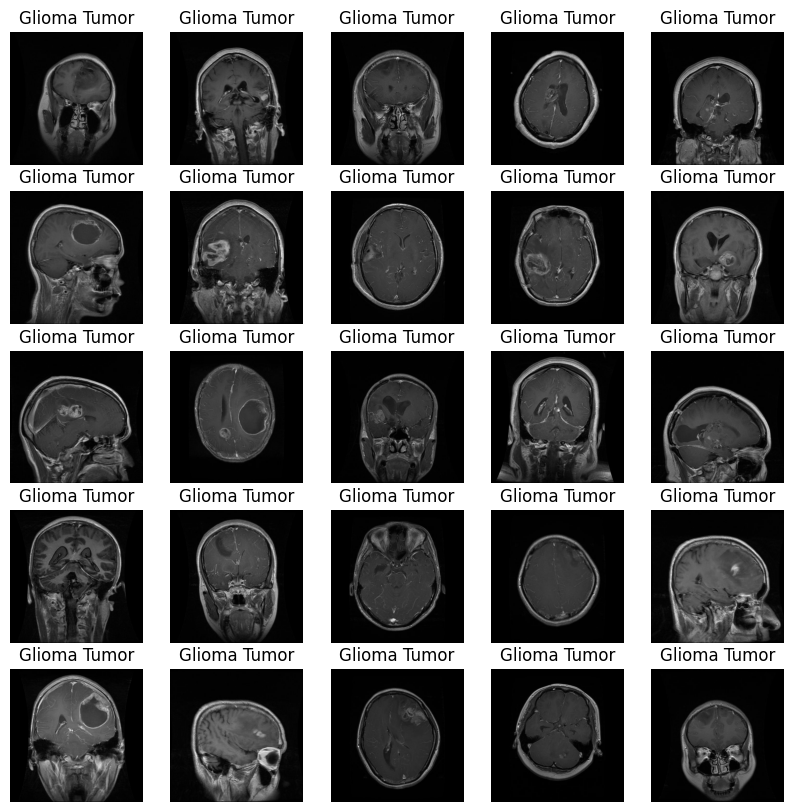

In [94]:
plt.figure(figsize=(10,10))
temp = train_df[train_df['label']=="glioma"]['images']
start = random.randint(0, len(temp))
                            #print(start)
                          #files = temp[start:start+25]
files=temp[0:25]       #Plotting first 25 Glioma images.
#plt.title("Normal Chest X ray Images", loc='center', fontsize=14, fontweight='bold', color='black', pad=15)
#print("\n \n \n")

for index, file in enumerate(files):
    plt.subplot(5,5, index+1)
    img = load_img(file)
    img = np.array(img)
    plt.imshow(img)
    plt.axis('off')
    plt.title('Glioma Tumor')


#Plotting first 25 Meningioma Tumor Images.

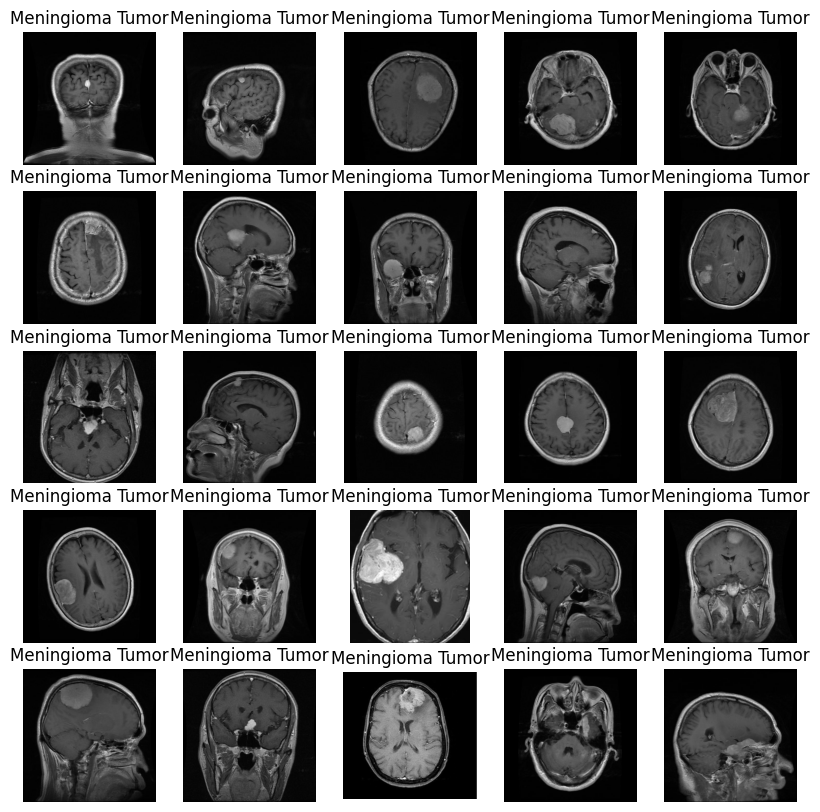

In [107]:
plt.figure(figsize=(10,10)) #Plotting First 25 Tuberculosis Chest X Ray Images.
temp = train_df[train_df['label']=="meningioma"]['images']
#start = random.randint(0, len(temp))
#print(start)
#files = temp[start:start+25]
files=temp[0:25] #Plotting first 25 images.
#plt.title("Tuebrculosis Chest X ray Images", loc='center', fontsize=14, fontweight='bold', color='black', pad=15)
print("\n \n \n")
for index, file in enumerate(files):
    plt.subplot(5,5, index+1)
    img = load_img(file)
    img = np.array(img)
    plt.imshow(img)
    plt.title('Meningioma Tumor')
    plt.axis('off')

#

#Plotting first 25 Pituitary Tumor Images.

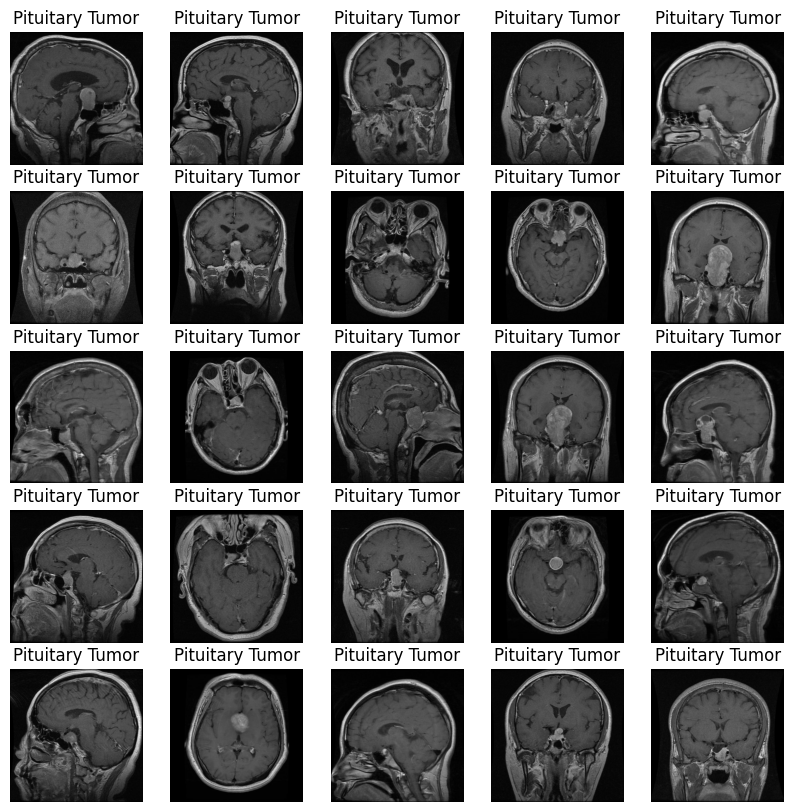

In [106]:
plt.figure(figsize=(10,10)) #Plotting First 25 Tuberculosis Chest X Ray Images.
temp = train_df[train_df['label']=="pituitary"]['images']
#start = random.randint(0, len(temp))
#print(start)
#files = temp[start:start+25]
files=temp[0:25] #Plotting first 25 images.
#plt.title("Tuebrculosis Chest X ray Images", loc='center', fontsize=14, fontweight='bold', color='black', pad=15)
print("\n \n \n")
for index, file in enumerate(files):
    plt.subplot(5,5, index+1)
    img = load_img(file)
    img = np.array(img)
    plt.imshow(img)
    plt.title('Pituitary Tumor')
    plt.axis('off')

#Plotting first Without Tumor Images.(Not having Tumor).



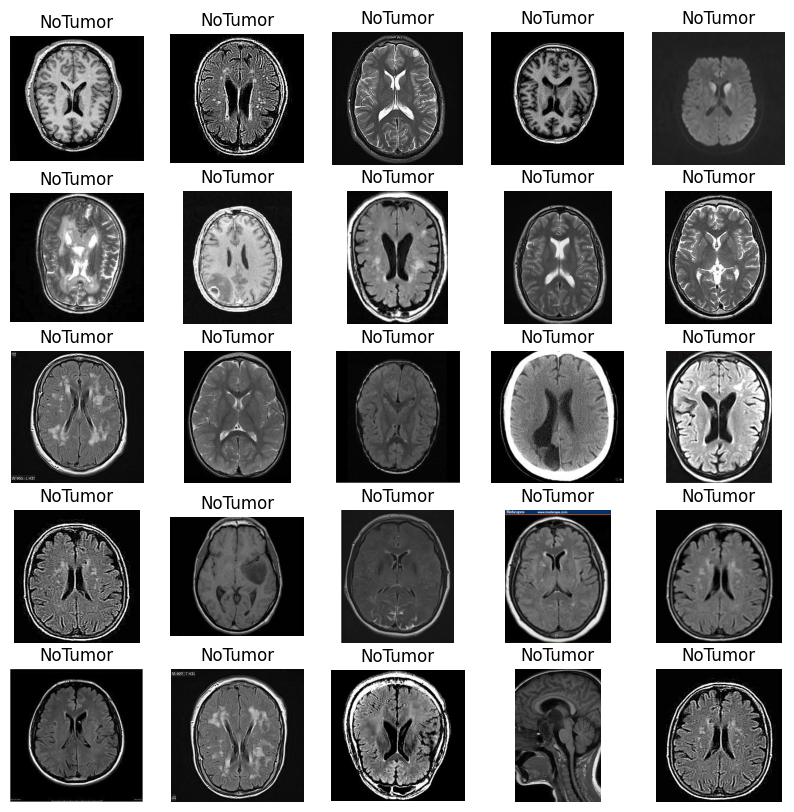

In [105]:
plt.figure(figsize=(10,10)) #Plotting First 25 Tuberculosis Chest X Ray Images.
temp = train_df[train_df['label']=="notumor"]['images']
#start = random.randint(0, len(temp))
#print(start)
#files = temp[start:start+25]
files=temp[0:25] #Plotting first 25 images.
#plt.title("Tuebrculosis Chest X ray Images", loc='center', fontsize=14, fontweight='bold', color='black', pad=15)
print("\n \n \n")
for index, file in enumerate(files):
    plt.subplot(5,5, index+1)
    img = load_img(file)
    img = np.array(img)
    plt.imshow(img)
    plt.title('NoTumor')
    plt.axis('off')

<Axes: xlabel='count', ylabel='label'>

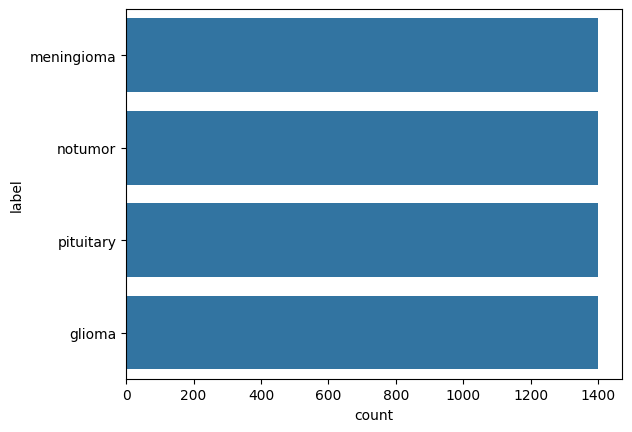

In [98]:
sns.countplot(train_df['label'])

In [29]:
train_df['label']=train_df['label'].astype("str")
train_df.head()

,images,label
0,/content/BrainTumorTraining/meningioma/Tr-me_7...,meningioma
1,/content/BrainTumorTraining/meningioma/Tr-me_6...,meningioma
2,/content/BrainTumorTraining/notumor/Tr-no_1167...,notumor
3,/content/BrainTumorTraining/meningioma/Tr-aug-...,meningioma
4,/content/BrainTumorTraining/meningioma/Tr-me_4...,meningioma


In [38]:
#from sklearn.model_selection import train_test_split
#train,test=train_test_split(df,test_size=0.2,random_state=42)

BATCH_SIZE = 32
IMG_SIZE = (512, 512)

# Load training data
train = tf.keras.utils.image_dataset_from_directory(
    '/content/BrainTumorTraining',
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)

# Load testing data
test = tf.keras.utils.image_dataset_from_directory(
    '/content/BrainTumorTesting',
    shuffle=False, # Usually False for testing/evaluation
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)

Found 5600 files belonging to 4 classes.
Found 1600 files belonging to 4 classes.


In [39]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.src.legacy.preprocessing.image import ImageDataGenerator
train_generator=ImageDataGenerator(
    rescale=1/255,
    #rotation_range=40, #To avoid overfitting.
    #shear_range=0.2,
    #zoom_range=0.2,
    #horizontal_flip=True,
    #fill_mode="nearest"
)
val_generator=ImageDataGenerator(rescale=1/255)
train_iterator=train_generator.flow_from_dataframe(
       #train,
       dataframe=train_df,
       directory='/content/BrainTumorTraining',    # Root folder containing train images
       x_col='images',
       y_col='label',
       target_size=(128, 128),
       batch_size=512,
       class_mode='categorical'
)


Found 5600 validated image filenames belonging to 4 classes.


In [42]:
val_iterator = val_generator.flow_from_dataframe(
     dataframe=test_df,
    directory='/content/BrainTumorTesting',
    x_col='images',
    y_col='label',
    target_size=(128, 128),
    batch_size=512,
    class_mode='categorical'
)

Found 1600 validated image filenames belonging to 4 classes.


In [43]:
from keras import Sequential
from keras.layers import Conv2D,MaxPool2D,Flatten,Dense
model = Sequential([
                    Conv2D(16, (3,3), activation='relu', input_shape=(128,128,3)),
                    MaxPool2D((2,2)),
                    Conv2D(32, (3,3), activation='relu'),
                    MaxPool2D((2,2)),
                    Conv2D(64, (3,3), activation='relu'),
                    MaxPool2D((2,2)),
                    Conv2D(128, (3,3), activation='relu'),
                    MaxPool2D((2,2)),
                    Conv2D(256, (3,3), activation='relu'),
                    MaxPool2D((2,2)),
                    Flatten(),
                    Dense(512, activation='relu'),
                    #Dense(1, activation='sigmoid')
                    Dense(4, activation='softmax')
])

In [44]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 919,460 (3.51 MB)

 Trainable params: 919,460 (3.51 MB)

 Non-trainable params: 0 (0.00 B)

In [45]:
history = model.fit(train_iterator, epochs=3, validation_data=val_iterator)

Epoch 1/3
11/11 ━━━━━━━━━━━━━━━━━━━━ 44s 3s/step - accuracy: 0.2505 - loss: 0.5808 - val_accuracy: 0.2575 - val_loss: 0.5498
Epoch 2/3
11/11 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - accuracy: 0.4729 - loss: 0.4970 - val_accuracy: 0.4981 - val_loss: 0.4921
Epoch 3/3
11/11 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.5895 - loss: 0.4246 - val_accuracy: 0.5894 - val_loss: 0.4503


#Results

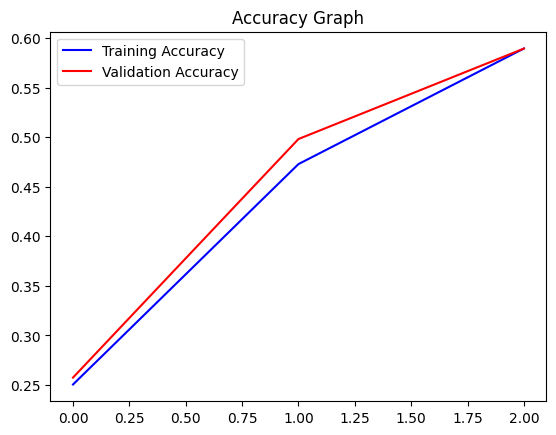

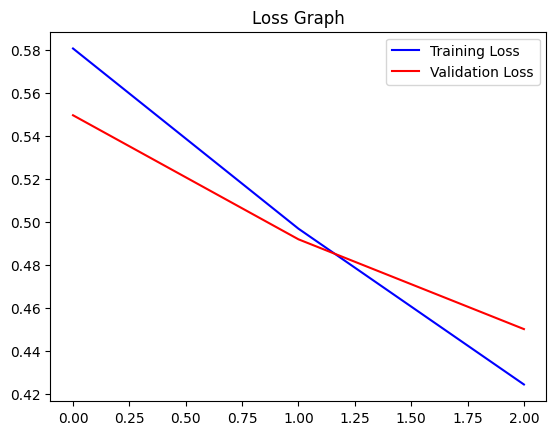

In [104]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs = range(len(acc))

plt.plot(epochs, acc, 'b', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation Accuracy')
plt.title('Accuracy Graph')
plt.legend()
plt.figure()

loss = history.history['loss']
val_loss = history.history['val_loss']
plt.plot(epochs, loss, 'b', label='Training Loss')
plt.plot(epochs, val_loss, 'r', label='Validation Loss')
plt.title('Loss Graph')
plt.legend()
plt.show()

#Testing on Unseen Brain Image.

#Testing with No Tumor Image.(Heathly Brain Image).

In [88]:

image_path="/content/BrainTumor_Testing/notumor/Te-no_102.jpg"
img = load_img(image_path, target_size=(128, 128))
img = np.array(img)
img = img / 255.0 # normalize the image
img = img.reshape(1, 128, 128, 3) # reshape for prediction
pred = model.predict(img)
print(pred)


# 1. Get the probability scores for all classes
class_probabilities = pred[0]

# 2. Get the predicted class index (highest probability)
predicted_class = np.argmax(pred[0])

print("Probabilities per class:", class_probabilities)
print("Predicted Class Index:", predicted_class)
if(predicted_class==0):
  print("Glioma Tumor")
elif(predicted_class==1):
  print("Meningioma Tumor")
elif(predicted_class==2):
  print("No Tumor")
else:
  print("Pituitary Tumor")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
[[0.00493363 0.02227962 0.92381173 0.04897492]]
Probabilities per class: [0.00493363 0.02227962 0.92381173 0.04897492]
Predicted Class Index: 2
No Tumor


#Testing with Glioma Tumor Image.

In [86]:
#image_path="/content/BrainTumorTesting/meningioma/Te-aug-me_1.jpg"
#image_path="/content/Glioma.jpg"

image_path="/content/BrainTumor_Testing/glioma/Te-gl_100.jpg"

img = load_img(image_path, target_size=(128, 128))
img = np.array(img)
img = img / 255.0 # normalize the image
img = img.reshape(1, 128, 128, 3) # reshape for prediction
pred = model.predict(img)
print(pred)


# 1. Get the probability scores for all classes
class_probabilities = pred[0]

# 2. Get the predicted class index (highest probability)
predicted_class = np.argmax(pred[0])

print("Probabilities per class:", class_probabilities)
print("Predicted Class Index:", predicted_class)
if(predicted_class==0):
  print("Glioma Tumor")
elif(predicted_class==1):
  print("Meningioma Tumor")
elif(predicted_class==2):
  print("No Tumor")
else:
  print("Pituitary Tumor")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
[[0.3712943  0.36635682 0.18666127 0.07568761]]
Probabilities per class: [0.3712943  0.36635682 0.18666127 0.07568761]
Predicted Class Index: 0
Glioma Tumor


#Testing with Meningioma Tumor Image.

In [89]:
image_path="/content/BrainTumor_Testing/meningioma/Te-aug-me_103.jpg"

img = load_img(image_path, target_size=(128, 128))
img = np.array(img)
img = img / 255.0 # normalize the image
img = img.reshape(1, 128, 128, 3) # reshape for prediction
pred = model.predict(img)
print(pred)


# 1. Get the probability scores for all classes
class_probabilities = pred[0]

# 2. Get the predicted class index (highest probability)
predicted_class = np.argmax(pred[0])

print("Probabilities per class:", class_probabilities)
print("Predicted Class Index:", predicted_class)
if(predicted_class==0):
  print("Glioma Tumor")
elif(predicted_class==1):
  print("Meningioma Tumor")
elif(predicted_class==2):
  print("No Tumor")
else:
  print("Pituitary Tumor")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
[[0.30065095 0.46846735 0.08210222 0.14877947]]
Probabilities per class: [0.30065095 0.46846735 0.08210222 0.14877947]
Predicted Class Index: 1
Meningioma Tumor


#Testing with Pituitary Tumor Image.

In [84]:
image_path="/content/BrainTumor_Testing/pituitary/Te-pi_101.jpg"

img = load_img(image_path, target_size=(128, 128))
img = np.array(img)
img = img / 255.0 # normalize the image
img = img.reshape(1, 128, 128, 3) # reshape for prediction
pred = model.predict(img)
print(pred)


# 1. Get the probability scores for all classes
class_probabilities = pred[0]

# 2. Get the predicted class index (highest probability)
predicted_class = np.argmax(pred[0])

print("Probabilities per class:", class_probabilities)
print("Predicted Class Index:", predicted_class)
if(predicted_class==0):
  print("Glioma Tumor")
elif(predicted_class==1):
  print("Meningioma Tumor")
elif(predicted_class==2):
  print("No Tumor")
else:
  print("Pituitary Tumor")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
[[0.05002623 0.1072419  0.10394586 0.73878604]]
Probabilities per class: [0.05002623 0.1072419  0.10394586 0.73878604]
Predicted Class Index: 3
Pituitary Tumor


In [ ]:
'''predicted_class = np.argmax(pred[0])
confidence_score = np.max(pred[0])

print(f"Probabilities per class: {pred[0]}")
print(f"Predicted Class: {predicted_class}")
print(f"Confidence: {confidence_score:.4f}")

if(predicted_class==0):
  print("Tuberculosis")
else:
  print("Normal")
'''